In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# Фиксация seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Загрузка датасета
dataset = load_dataset("emotion")
print(dataset)

# Посмотрим на распределение классов в train
train_df = pd.DataFrame(dataset["train"])
print("Train set size:", len(train_df))
print("\nClass distribution in train:")
print(train_df["label"].value_counts().sort_index())

# Соответствие label -> emotion name
label_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# Несколько примеров
print("\nSample examples:")
for i in range(5):
    example = dataset["train"][i]
    print(f"Text: {example['text'][:80]}... | Label: {example['label']} ({label_names[example['label']]})")

# Возьмём маленькую модель для демонстрации токенизации (используем ту же, что и для fine-tuning)
demo_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_text = dataset["train"][0]["text"]
print("Original text:", sample_text)
print("\nTokenization:")
tokens = demo_tokenizer.tokenize(sample_text)
print("Tokens:", tokens)
print("Number of tokens:", len(tokens))

# Кодирование
encoded = demo_tokenizer(sample_text, return_tensors="pt")
print("\ninput_ids shape:", encoded["input_ids"].shape)
print("input_ids:", encoded["input_ids"][0].tolist())
print("attention_mask:", encoded["attention_mask"][0].tolist())

# Декодирование обратно
decoded = demo_tokenizer.decode(encoded["input_ids"][0])
print("\nDecoded text:", decoded)

# Special tokens
print("\nSpecial tokens:")
print(f"CLS: {demo_tokenizer.cls_token} (id={demo_tokenizer.cls_token_id})")
print(f"SEP: {demo_tokenizer.sep_token} (id={demo_tokenizer.sep_token_id})")
print(f"PAD: {demo_tokenizer.pad_token} (id={demo_tokenizer.pad_token_id})")
print(f"UNK: {demo_tokenizer.unk_token} (id={demo_tokenizer.unk_token_id})")

# Пример padding и truncation
long_text = " ".join(["word"] * 200)
short_text = "short example"
encoded_batch = demo_tokenizer([short_text, long_text], padding=True, truncation=True, max_length=50, return_tensors="pt")
print("\nPadding/truncation demo:")
print(f"Short text input_ids shape: {encoded_batch['input_ids'][0].shape}")
print(f"Long text input_ids shape: {encoded_batch['input_ids'][1].shape}")
print(f"Attention mask for long text (last 10): {encoded_batch['attention_mask'][1][-10:].tolist()}")

Using device: cpu
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Train set size: 16000

Class distribution in train:
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

Sample examples:
Text: i didnt feel humiliated... | Label: 0 (sadness)
Text: i can go from feeling so hopeless to so damned hopeful just from being around so... | Label: 0 (sadness)
Text: im grabbing a minute to post i feel greedy wrong... | Label: 3 (anger)
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on ... | Label: 2 (love)
Text: i am feeling grouchy... | Label: 3 (anger)
Original text: i didnt feel humiliated

Tokenization:
Tokens: ['i', 'didn', '##t', 'feel', 'humiliated']
Number of tokens: 5

input_ids

In [2]:
from transformers import pipeline

# Загружаем pipeline для анализа тональности (на русском/английском)
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=0 if torch.cuda.is_available() else -1)

# Выберем несколько примеров из validation
test_samples = dataset["validation"].select([0, 5, 10, 15, 20])
texts = [sample["text"] for sample in test_samples]
true_labels = [label_names[sample["label"]] for sample in test_samples]

# Инференс
predictions = sentiment_pipeline(texts)

# Вывод результатов
results_df = pd.DataFrame({
    "text": texts,
    "true_emotion": true_labels,
    "predicted_stars": [p["label"] for p in predictions],
    "confidence": [p["score"] for p in predictions]
})
print("Inference results with sentiment model:")
results_df

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Функция токенизации датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

# Применяем токенизацию ко всем сплитам
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Удаляем столбец "text" (он больше не нужен, т.к. строка не конвертируется в тензор)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Устанавливаем формат тензоров
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_dataset)

# Data collator для динамического padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

print(f"Model loaded: {model_name}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    f1_weighted = f1_score(labels, predictions, average="weighted")
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir="./hw13_finetuned_emotion",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    push_to_hub=False,
    logging_steps=50,
    report_to="none",
)

# Совместимость с разными версиями transformers
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

trainer.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Inference results with sentiment model:


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | Details
------------------------+------------+--------
vocab_layer_norm.bias   | UNEXPECTED |        
vocab_transform.bias    | UNEXPECTED |        
vocab_projector.bias    | UNEXPECTED |        
vocab_transform.weight  | UNEXPECTED |        
vocab_layer_norm.weight | UNEXPECTED |        
pre_classifier.bias     | MISSING    |        
classifier.weight       | MISSING    |        
pre_classifier.weight   | MISSING    |        
classifier.bias         | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

C:\Users\Ivan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.247985,0.206254,0.928500,0.898552,0.928386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1000, training_loss=0.5151021099090576, metrics={'train_runtime': 1496.7798, 'train_samples_per_second': 10.69, 'train_steps_per_second': 0.668, 'total_flos': 194625049506048.0, 'train_loss': 0.5151021099090576, 'epoch': 1.0})

C:\Users\Ivan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.2063
eval_accuracy: 0.9285
eval_f1_macro: 0.8986
eval_f1_weighted: 0.9284
eval_runtime: 44.8934
eval_samples_per_second: 44.5500
eval_steps_per_second: 2.7840
epoch: 1.0000


C:\Users\Ivan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test metrics:
eval_loss: 0.2234
eval_accuracy: 0.9155
eval_f1_macro: 0.8725
eval_f1_weighted: 0.9156
eval_runtime: 45.2350
eval_samples_per_second: 44.2140
eval_steps_per_second: 2.7630
epoch: 1.0000


C:\Users\Ivan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Classification Report on test set:
              precision    recall  f1-score   support

     sadness       0.96      0.95      0.95       581
         joy       0.94      0.94      0.94       695
        love       0.79      0.82      0.80       159
       anger       0.92      0.91      0.91       275
        fear       0.88      0.89      0.88       224
    surprise       0.76      0.73      0.74        66

    accuracy                           0.92      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.92      0.92      0.92      2000



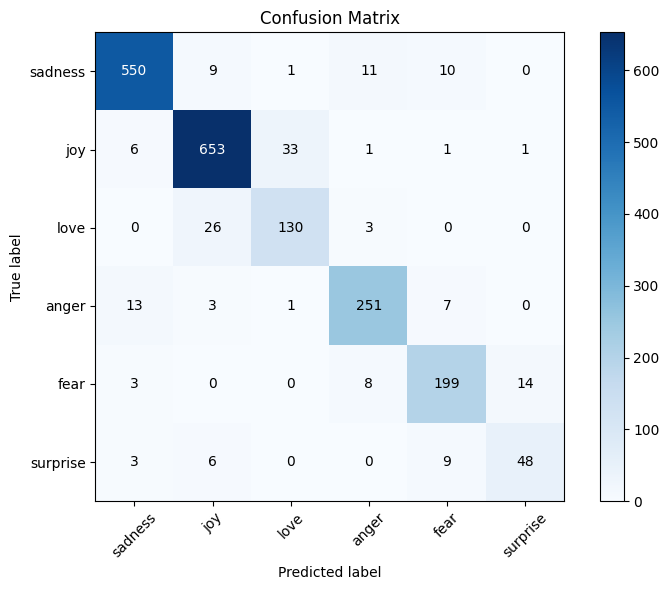

Confusion matrix saved to artifacts/confusion_matrix.png
Sample predictions saved to artifacts/sample_predictions.csv

First 10 predictions:
                                                text true_label pred_label  \
0            i feel a little nervous i go to the gym       fear       fear   
1                    i feel like it might just be ok        joy        joy   
2  i am going to actively learn more about these ...        joy        joy   
3  when we rearranged furniture in our flat and g...      anger      anger   
4  i cant do strappy shoes at work i just feel we...       fear   surprise   
5  i feel so thrilled to have three such distingu...        joy        joy   
6  ive been getting have been making me feel susp...       fear       fear   
7                              im not feeling mellow        joy        joy   
8  i wanna feel that gorgeous body a yers underne...        joy        joy   
9  i feel the need to compensate with only the mo...        joy        joy   



In [4]:
# Удаляем проблемный колбэк NotebookProgressCallback (баг transformers в Jupyter)
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка на validation
val_metrics = trainer.evaluate(tokenized_dataset["validation"])
print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

# Оценка на test
test_metrics = trainer.evaluate(tokenized_dataset["test"])
print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

# Предсказания на test (получаем логиты и метки)
test_predictions = trainer.predict(tokenized_dataset["test"])
logits = test_predictions.predictions
true_labels = test_predictions.label_ids
pred_labels = np.argmax(logits, axis=-1)

# Classification report (детализация по каждому классу)
print("\nClassification Report on test set:")
print(classification_report(true_labels, pred_labels, target_names=list(id2label.values()), zero_division=0))

# --- Матрица ошибок (confusion matrix) ---
# Создаём папку artifacts, если её нет
import os
os.makedirs("artifacts", exist_ok=True)

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(id2label))
plt.xticks(tick_marks, id2label.values(), rotation=45)
plt.yticks(tick_marks, id2label.values())
plt.ylabel("True label")
plt.xlabel("Predicted label")

# Добавляем числа в ячейки
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved to artifacts/confusion_matrix.png")

# --- Примеры предсказаний для sample_predictions.csv ---
# Берём случайные 20 примеров из test (или меньше, если датасет маленький)
test_dataset_full = dataset["test"]  # исходный датасет (не токенизированный)
num_samples = min(20, len(test_dataset_full))
indices = random.sample(range(len(test_dataset_full)), num_samples)

sample_texts = [test_dataset_full[i]["text"] for i in indices]
sample_true = [test_dataset_full[i]["label"] for i in indices]

# Токенизация для инференса (используем тот же токенизатор)
encodings = tokenizer(sample_texts, truncation=True, padding=True, max_length=128, return_tensors="pt")
encodings = {k: v.to(device) for k, v in encodings.items()}

model.eval()
with torch.no_grad():
    outputs = model(**encodings)
    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=-1)

# Формируем DataFrame
sample_df = pd.DataFrame({
    "text": sample_texts,
    "true_label": [id2label[t] for t in sample_true],
    "pred_label": [id2label[p] for p in preds],
    "confidence": [probs[i][preds[i]] for i in range(len(preds))]
})

# Сохраняем в CSV
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("Sample predictions saved to artifacts/sample_predictions.csv")
print("\nFirst 10 predictions:")
print(sample_df.head(10))

# Находим все ошибочные предсказания на тесте (используем уже полученные true_labels и pred_labels)
test_texts_full = dataset["test"]["text"]
error_indices = [i for i, (true, pred) in enumerate(zip(true_labels, pred_labels)) if true != pred]
print(f"\nTotal errors: {len(error_indices)} out of {len(true_labels)} ({100*len(error_indices)/len(true_labels):.1f}%)")

# Показываем первые 5 ошибок (или меньше)
print("\nFirst 5 error examples:")
for i in error_indices[:5]:
    true_emotion = id2label[true_labels[i]]
    pred_emotion = id2label[pred_labels[i]]
    print(f"Text: {test_texts_full[i][:100]}...")
    print(f"True: {true_emotion}, Predicted: {pred_emotion}")
    print("-" * 50)